# 03 · Caso de estudio: precios de combustible en Guatemala

El proyecto final (PF-ML) quiere predecir si el precio de la gasolina de la **siguiente
semana** sube, baja o se mantiene. El problema: **los datos no existen**. Los precios
viven en fotografías de surtidores Shell.

Este notebook tiene dos partes:

**Parte A — Los datos reales del piloto** (5 fotos, valores copiados de
`PF-ML/data/lecturas_manuales.csv` y `PF-ML/output/gas_prices.csv`):
1. Reproducir las reglas de negocio de `gas_pipeline.py` y sus *flags*.
2. Ver por qué Diesel no se estima.
3. Unir el contexto externo (Brent) **sin mirar el futuro** (`merge_asof`).
4. Convertir los precios en etiquetas BAJA/ESTABLE/SUBE y darnos cuenta de que con 5
   fotos no se puede entrenar nada.

**Parte B — Simulación de lo que vendrá** (serie semanal sintética de 4 años):
5. Elegir el umbral ε.
6. Separar en el tiempo, comparar contra las dos líneas base del PDF y medir Macro-F1.
7. Ver con números dos trampas: la **fuga temporal** y el **split aleatorio**.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import KFold, TimeSeriesSplit, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)
plt.rcParams["figure.dpi"] = 100

# Parte A — El piloto real

## 1. Las cinco fotografías

Cada foto de un surtidor muestra: el **total de la venta** (Q150.00), los **galones**
despachados y, en cuatro pantallas LCD inferiores, el precio por galón de Diesel,
Regular, Súper y V-Power. La fecha sale de la metadata EXIF (ExifTool) y la lectura de
los precios es **manual** (un humano mira la foto).

In [2]:
piloto = pd.DataFrame({
    "archivo":   ["IMG_8271", "IMG_8286", "IMG_8304", "IMG_8322", "IMG_8325"],
    "fecha":     pd.to_datetime(["2026-07-09 19:42:19", "2026-07-15 19:57:16", "2026-07-22 21:50:33",
                                 "2026-07-26 18:11:25", "2026-07-30 20:00:51"]),
    "total_venta": [150.00] * 5,
    "galones":   [3.938, 3.789, 3.651, 3.564, 3.564],
    "diesel":    [39.39, 39.39, 40.29, 43.19, 43.79],
    "regular":   [37.09, 38.59, 40.09, 41.09, 41.09],
    "super":     [38.09, 39.59, 41.09, 42.09, 42.09],
    "vpower":    [38.59, 40.09, 41.59, 42.59, 42.59],
})
piloto

,archivo,fecha,total_venta,galones,diesel,regular,super,vpower
0,IMG_8271,2026-07-09 19:42:19,150.0,3.938,39.39,37.09,38.09,38.59
1,IMG_8286,2026-07-15 19:57:16,150.0,3.789,39.39,38.59,39.59,40.09
2,IMG_8304,2026-07-22 21:50:33,150.0,3.651,40.29,40.09,41.09,41.59
3,IMG_8322,2026-07-26 18:11:25,150.0,3.564,43.19,41.09,42.09,42.59
4,IMG_8325,2026-07-30 20:00:51,150.0,3.564,43.79,41.09,42.09,42.59


## 2. Las reglas de negocio y los *flags*

El pipeline **no confía en una sola lectura**: calcula los precios de otra forma y
compara. Las reglas observadas en esta estación Shell:

- **Súper** = total de la venta / galones (la venta de la foto fue de Súper).
- **Regular** = Súper − Q1.00.
- **V-Power** = Súper + Q0.50.

Si la diferencia entre lo estimado y lo leído es ≤ Q0.02 (`MATCH_TOLERANCE`), el *flag*
de ese combustible vale 1. Si los tres coinciden, `estado_flag = ENCENDIDO`; si falta
algo o no se detectan las 4 pantallas, `requiere_revision_flag = 1`.
Reproducimos `calcular_estimados()` y `comparar()` de `src/gas_pipeline.py`:

In [3]:
TOLERANCIA = 0.02

def calcular_estimados(total, galones):
    super_ = round(total / galones, 2)
    return round(super_ - 1.0, 2), super_, round(super_ + 0.5, 2)

def comparar(estimado, manual):
    diferencia = round(estimado - manual, 2)
    return diferencia, int(abs(diferencia) <= TOLERANCIA)

filas = []
for _, r in piloto.iterrows():
    reg_est, sup_est, vp_est = calcular_estimados(r.total_venta, r.galones)
    d_r, f_r = comparar(reg_est, r.regular)
    d_s, f_s = comparar(sup_est, r.super)
    d_v, f_v = comparar(vp_est, r.vpower)
    todos = int(f_r == f_s == f_v == 1)
    filas.append({"archivo": r.archivo, "super_division": sup_est, "dif_regular": d_r,
                  "dif_super": d_s, "dif_vpower": d_v, "todos_match_flag": todos,
                  "estado_flag": "ENCENDIDO" if todos else "APAGADO",
                  "requiere_revision_flag": int(not todos)})
flags = pd.DataFrame(filas)
flags

,archivo,super_division,dif_regular,dif_super,dif_vpower,todos_match_flag,estado_flag,requiere_revision_flag
0,IMG_8271,38.09,0.00,0.00,0.00,1,ENCENDIDO,0
1,IMG_8286,39.59,0.00,0.00,0.00,1,ENCENDIDO,0
2,IMG_8304,41.08,-0.01,-0.01,-0.01,1,ENCENDIDO,0
3,IMG_8322,42.09,0.00,0.00,0.00,1,ENCENDIDO,0
4,IMG_8325,42.09,0.00,0.00,0.00,1,ENCENDIDO,0


**Interpretación:** las cinco fotos quedan con `ENCENDIDO` y sin revisión pendiente, igual
que en `output/gas_prices.csv` del repo. El único detalle es IMG_8304: 150 / 3.651 =
41.08, uno menos que el 41.09 leído. Es **redondeo** de los galones (la bomba muestra 3
decimales), por eso la tolerancia es de 2 centavos y no de cero. Diseñar la tolerancia
pensando en la precisión de la medición es una decisión de negocio, no un detalle.

Comprobemos que una lectura mal hecha sí enciende la alarma (es la prueba unitaria
`test_precio_fuera_de_tolerancia_apaga_flag` del repo):

In [4]:
print("Lectura correcta (41.08 vs 41.09):", comparar(41.08, 41.09))
print("Lectura errónea  (41.00 vs 41.09):", comparar(41.00, 41.09))

Lectura correcta (41.08 vs 41.09): (-0.01, 1)
Lectura errónea  (41.00 vs 41.09): (-0.09, 0)


## 3. ¿Por qué Diesel no se estima?
Si Diesel tuviera una diferencia fija respecto a Súper (como Regular y V-Power), también
se podría validar. Medimos esa diferencia en cada foto:

In [5]:
spreads = pd.DataFrame({
    "fecha": piloto.fecha.dt.date,
    "regular_menos_super": (piloto.regular - piloto.super).round(2),
    "vpower_menos_super": (piloto.vpower - piloto.super).round(2),
    "diesel_menos_super": (piloto.diesel - piloto.super).round(2),
})
print(spreads.to_string(index=False))
print("\nRango de la diferencia Diesel - Súper:",
      spreads.diesel_menos_super.min(), "a", spreads.diesel_menos_super.max())

     fecha  regular_menos_super  vpower_menos_super  diesel_menos_super
2026-07-09                 -1.0                 0.5                 1.3
2026-07-15                 -1.0                 0.5                -0.2
2026-07-22                 -1.0                 0.5                -0.8
2026-07-26                 -1.0                 0.5                 1.1
2026-07-30                 -1.0                 0.5                 1.7

Rango de la diferencia Diesel - Súper: -0.8 a 1.7


**Interpretación:** Regular − Súper es **−1.00 en las cinco fotos** y V-Power − Súper es
**+0.50 en las cinco**, pero Diesel − Súper va de **−0.80 a +1.70**. Diesel tiene su propia
dinámica (otro producto refinado, otra demanda: transporte de carga, agricultura), así
que inventarle una regla generaría datos falsos. El pipeline lo **almacena** tal como se
lee, pero no lo estima. El PDF también advierte que estas reglas son de *esta* estación
Shell y no deben aplicarse automáticamente a otras marcas.

## 4. Contexto externo sin mirar el futuro

`external_data.py` descarga el precio diario del Brent (FRED/EIA) y a cada foto le asigna
**la última observación disponible en o antes de la fecha de la foto**. Nunca una
posterior: el modelo final se usará el lunes para predecir la semana, y el lunes no se
conoce el Brent del miércoles.

En pandas eso es `merge_asof(..., direction="backward")`. Usamos los valores reales del
Brent guardados en `data/external/series_mercado.csv` (del 29 de junio al 30 de julio de
2026; los fines de semana no hay cotización).

In [6]:
brent = pd.DataFrame({
    "fecha_mercado": pd.to_datetime([
        "2026-06-29", "2026-06-30", "2026-07-01", "2026-07-02", "2026-07-03", "2026-07-06",
        "2026-07-07", "2026-07-08", "2026-07-09", "2026-07-10", "2026-07-13", "2026-07-14",
        "2026-07-15", "2026-07-16", "2026-07-17", "2026-07-20", "2026-07-21", "2026-07-22",
        "2026-07-23", "2026-07-24", "2026-07-27", "2026-07-28", "2026-07-29", "2026-07-30"]),
    "brent_usd": [71.59, 70.46, 69.24, 68.53, 68.68, 69.56, 71.78, 76.50, 74.46, 74.34, 81.62,
                  83.69, 83.08, 81.23, 85.01, 86.99, 93.85, 94.12, 105.32, 100.31, 91.82,
                  85.51, 91.95, 91.91],
})

fotos = piloto[["archivo", "fecha"]].assign(dia=piloto.fecha.dt.normalize())
ctx = pd.merge_asof(fotos.sort_values("dia"), brent, left_on="dia", right_on="fecha_mercado",
                    direction="backward")
# variación de 7 días: Brent de hoy contra el último disponible 7 días antes
hace7 = pd.merge_asof(fotos.assign(dia7=fotos.dia - pd.Timedelta(days=7)).sort_values("dia7"),
                      brent.rename(columns={"brent_usd": "brent_7d_antes"}),
                      left_on="dia7", right_on="fecha_mercado", direction="backward")
ctx["brent_7d_antes"] = hace7["brent_7d_antes"].values
ctx["variacion_brent_7d_pct"] = ((ctx.brent_usd / ctx.brent_7d_antes - 1) * 100).round(2)
ctx[["archivo", "dia", "fecha_mercado", "brent_usd", "variacion_brent_7d_pct"]]

,archivo,dia,fecha_mercado,brent_usd,variacion_brent_7d_pct
0,IMG_8271,2026-07-09,2026-07-09,74.46,8.65
1,IMG_8286,2026-07-15,2026-07-15,83.08,8.60
2,IMG_8304,2026-07-22,2026-07-22,94.12,13.29
3,IMG_8322,2026-07-26,2026-07-24,100.31,18.00
4,IMG_8325,2026-07-30,2026-07-30,91.91,-12.73


**Interpretación:** fíjate en IMG_8322 (domingo 26 de julio): no hay Brent ese día, así
que toma el del **viernes 24** (100.31), nunca el del lunes 27. Los valores coinciden con
las columnas `fecha_mercado`, `brent_usd_barril` y `variacion_brent_7d_pct` del CSV del
repo (8.65, 8.6, 13.29, 18.0, −12.73). Lo mismo se hace con los eventos globales: solo
cuentan los que empezaron **antes** de la foto, dentro de una ventana de 21 días (la prueba
`test_contexto_solo_usa_datos_anteriores` verifica que un "evento futuro" no se cuele).

## 5. De precios a etiquetas: ¿alcanza el piloto?

La variable objetivo del PDF, para una estación $s$, un combustible $f$ y una semana $t$:

$$\Delta P_{t+1} = P_{t+1} - P_t, \qquad
y_{t+1} = \begin{cases} \text{BAJA} & \Delta P_{t+1} < -\varepsilon \\
\text{ESTABLE} & |\Delta P_{t+1}| \le \varepsilon \\
\text{SUBE} & \Delta P_{t+1} > \varepsilon \end{cases}$$

Apliquémoslo a Regular con un ε provisional de Q0.15:

In [7]:
def etiquetar(cambio, eps):
    return np.select([cambio < -eps, cambio > eps], ["BAJA", "SUBE"], "ESTABLE")

reg = piloto[["fecha", "regular"]].copy()
reg["dias_desde_anterior"] = reg.fecha.dt.normalize().diff().dt.days
reg["cambio"] = reg.regular.diff().round(2)
reg["etiqueta"] = np.where(reg.cambio.isna(), "—", etiquetar(reg.cambio.fillna(0), 0.15))
print(reg.to_string(index=False))
print(f"\nCambio total de Regular en el periodo: Q{piloto.regular.iloc[-1] - piloto.regular.iloc[0]:.2f}")
print(f"Cambio total de Diesel en el periodo:  Q{piloto.diesel.iloc[-1] - piloto.diesel.iloc[0]:.2f}")

              fecha  regular  dias_desde_anterior  cambio etiqueta
2026-07-09 19:42:19    37.09                  NaN     NaN        —
2026-07-15 19:57:16    38.59                  6.0     1.5     SUBE
2026-07-22 21:50:33    40.09                  7.0     1.5     SUBE
2026-07-26 18:11:25    41.09                  4.0     1.0     SUBE
2026-07-30 20:00:51    41.09                  4.0     0.0  ESTABLE

Cambio total de Regular en el periodo: Q4.00
Cambio total de Diesel en el periodo:  Q4.40


**Interpretación:** con 5 fotos hay **4 cambios**, tres SUBE y un ESTABLE, ninguna BAJA.
Además las fotos no están separadas exactamente una semana (6, 7, 4 y 4 días de
calendario), así que
antes de modelar habrá que definir qué es "la semana t" (por ejemplo, el último precio
observado de cada semana). Regular subió Q4.00 y Diesel Q4.40 en tres semanas, justo cuando
el Brent pasó de ~74 a ~92 dólares. Pero eso es una **descripción**, no un modelo: el PDF
lo dice claro, "cinco fotografías de una estación no permiten generalizar ni predecir".
La entrega del Caso 1 valida el **pipeline de captura**; la predicción llega cuando haya
historia.

# Parte B — Simulación: cuando ya haya historia

Para practicar la parte de modelado sin esperar meses de fotos, generamos una serie
**sintética** de 4 años (208 semanas) que imita la idea del proyecto: el precio local
sigue al Brent **con una semana de rezago**, más ruido.

- `brent`: caminata aleatoria con inercia (si subió esta semana, tiende a seguir subiendo).
- `precio`: cada semana cambia 0.10 Q por cada dólar que cambió el Brent la semana
  anterior, más 0.05 Q por el de hace dos semanas, más ruido.

Los números son inventados; lo que importa es el **método**.

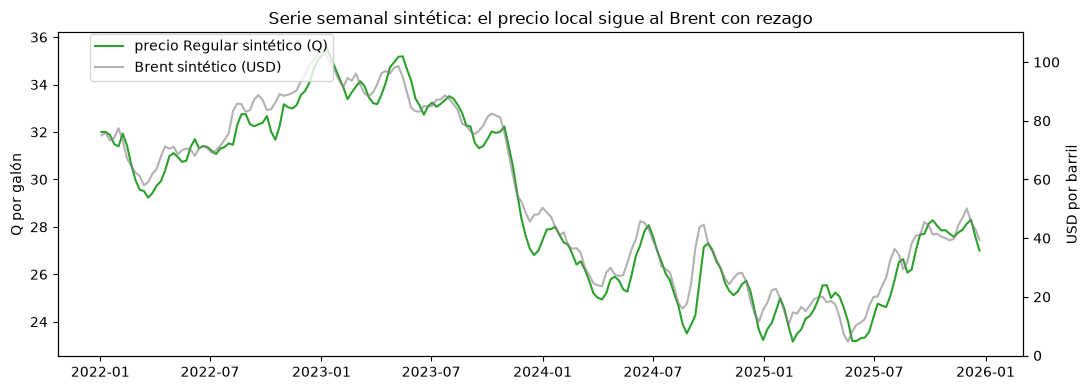

In [8]:
rng = np.random.default_rng(RANDOM_STATE)
n = 208
d_brent = np.zeros(n)
for t in range(1, n):
    d_brent[t] = 0.5 * d_brent[t - 1] + rng.normal(0, 3)
d_precio = np.zeros(n)
for t in range(2, n):
    d_precio[t] = 0.10 * d_brent[t - 1] + 0.05 * d_brent[t - 2] + rng.normal(0, 0.18)

serie = pd.DataFrame({
    "semana": pd.date_range("2022-01-03", periods=n, freq="W-MON"),
    "brent": (75 + np.cumsum(d_brent)).round(2),
    "precio": (32 + np.cumsum(d_precio)).round(2),
})

fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.plot(serie.semana, serie.precio, c="tab:green", label="precio Regular sintético (Q)")
ax1.set_ylabel("Q por galón")
ax2 = ax1.twinx()
ax2.plot(serie.semana, serie.brent, c="tab:gray", alpha=0.6, label="Brent sintético (USD)")
ax2.set_ylabel("USD por barril")
ax1.set_title("Serie semanal sintética: el precio local sigue al Brent con rezago")
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.92))
plt.tight_layout()
plt.show()

## 6. Elegir ε con la distribución real de los cambios

El PDF dice que ε "se definirá durante el entendimiento de los datos según la precisión
de las lecturas y la distribución real de los cambios". Veamos qué proporción de clases
produce cada ε:

In [9]:
serie["cambio"] = serie.precio.diff()
serie["cambio_siguiente"] = serie.cambio.shift(-1)          # ΔP_{t+1}: lo que queremos predecir

print("Tamaño del cambio semanal |ΔP| (Q):")
print(serie.cambio.abs().describe().round(3))

tabla_eps = pd.DataFrame({
    f"ε = {e:.2f}": pd.Series(etiquetar(serie.cambio_siguiente.dropna(), e)).value_counts(normalize=True)
    for e in [0.02, 0.05, 0.15, 0.30, 0.50]
}).fillna(0).round(3)
tabla_eps

Tamaño del cambio semanal |ΔP| (Q):
count    207.000
mean       0.361
std        0.258
min        0.000
25%        0.160
50%        0.330
75%        0.510
max        1.450
Name: cambio, dtype: float64


,ε = 0.02,ε = 0.05,ε = 0.15,ε = 0.30,ε = 0.50
BAJA,0.488,0.473,0.396,0.309,0.145
ESTABLE,0.039,0.063,0.232,0.464,0.744
SUBE,0.473,0.464,0.372,0.227,0.111


**Interpretación:** con ε = 0.02 (la tolerancia de lectura) solo el 3.9 % de las semanas
queda ESTABLE, y con ε = 0.50 el 74.4 % queda ESTABLE y el modelo podría "ganar" diciendo
siempre ESTABLE.
Elegimos **ε = 0.15** (valor nuestro para practicar; el proyecto aún no lo fija): por
encima del error de lectura (0.02) y deja las tres clases representadas (39.6 % BAJA,
23.2 % ESTABLE, 37.2 % SUBE) (ESTABLE es la minoritaria, por eso la métrica será **Macro-F1**, que le da
el mismo peso que a las otras dos, como pide el PDF).

In [10]:
EPS = 0.15
serie["y"] = pd.Series(etiquetar(serie.cambio_siguiente, EPS), index=serie.index).where(
    serie.cambio_siguiente.notna())
serie["y_actual"] = pd.Series(etiquetar(serie.cambio, EPS), index=serie.index)  # dirección de ESTA semana

## 7. Variables: solo lo que se conoce el lunes de la semana t

Variables **honestas** (todas calculadas con datos hasta la semana t):

| Variable | Qué es |
|---|---|
| `cambio_t` | ΔP de esta semana |
| `cambio_t_1` | ΔP de la semana pasada |
| `brent_cambio_t` | cambio del Brent esta semana |
| `brent_cambio_t_1` | cambio del Brent la semana pasada |

Y una variable **con fuga temporal**, un error muy común: un promedio móvil **centrado**
(`rolling(3, center=True)`) usa la semana t−1, la t **y la t+1**. Se ve inocente, pero
contiene el precio de la semana que queremos predecir.

In [11]:
serie["cambio_t"] = serie.cambio
serie["cambio_t_1"] = serie.cambio.shift(1)
serie["brent_cambio_t"] = serie.brent.diff()
serie["brent_cambio_t_1"] = serie.brent.diff().shift(1)
serie["media_movil_centrada"] = serie.precio.rolling(3, center=True).mean() - serie.precio  # ¡FUGA!

HONESTAS = ["cambio_t", "cambio_t_1", "brent_cambio_t", "brent_cambio_t_1"]
NIVELES = ["precio", "brent"]                    # niveles absolutos (no estacionarios)
CON_FUGA = HONESTAS + ["media_movil_centrada"]

datos = serie.dropna(subset=HONESTAS + ["media_movil_centrada", "y"]).reset_index(drop=True)
print("Semanas utilizables:", len(datos))
print(datos.y.value_counts().to_dict())

Semanas utilizables: 205
{'BAJA': 82, 'SUBE': 77, 'ESTABLE': 46}


## 8. Split temporal y las dos líneas base del PDF

Entrenamos con el **75 % más antiguo** y probamos con el **25 % más reciente**. Nunca al
revés y nunca barajado: en producción siempre se predice el futuro con el pasado.

Criterios de éxito del PDF: el modelo debe superar en **Macro-F1** a una línea base que
siempre predice la clase mayoritaria **o** que repite la tendencia anterior.

In [12]:
corte = int(len(datos) * 0.75)
train, test = datos.iloc[:corte], datos.iloc[corte:]
print(f"Train: {train.semana.min():%Y-%m-%d} a {train.semana.max():%Y-%m-%d} ({len(train)} semanas)")
print(f"Test:  {test.semana.min():%Y-%m-%d} a {test.semana.max():%Y-%m-%d} ({len(test)} semanas)")

mayoritaria = train.y.mode()[0]
f1_mayoritaria = f1_score(test.y, [mayoritaria] * len(test), average="macro")
f1_persistencia = f1_score(test.y, test.y_actual, average="macro")

modelo = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
modelo.fit(train[HONESTAS], train.y)
pred = modelo.predict(test[HONESTAS])
f1_modelo = f1_score(test.y, pred, average="macro")

print(f"\nBaseline clase mayoritaria ('{mayoritaria}'): Macro-F1 = {f1_mayoritaria:.3f}")
print(f"Baseline persistencia (repite la semana t):    Macro-F1 = {f1_persistencia:.3f}")
print(f"Regresión logística (variables honestas):      Macro-F1 = {f1_modelo:.3f}")
print()
print(classification_report(test.y, pred, digits=3))

Train: 2022-01-17 a 2024-12-16 (153 semanas)
Test:  2024-12-23 a 2025-12-15 (52 semanas)

Baseline clase mayoritaria ('BAJA'): Macro-F1 = 0.149
Baseline persistencia (repite la semana t):    Macro-F1 = 0.449
Regresión logística (variables honestas):      Macro-F1 = 0.694

              precision    recall  f1-score   support

        BAJA      0.867     0.867     0.867        15
     ESTABLE      0.571     0.308     0.400        13
        SUBE      0.733     0.917     0.815        24

    accuracy                          0.750        52
   macro avg      0.724     0.697     0.694        52
weighted avg      0.731     0.750     0.726        52



**Interpretación:** la clase mayoritaria (BAJA en train) saca Macro-F1 = **0.149**: acierta
una clase y falla las otras dos (y además en el test la clase más común resultó ser SUBE:
la mayoría del pasado no es la del futuro). La persistencia llega a **0.449**, porque el
Brent tiene inercia. La regresión logística con variables honestas logra **0.694** y supera
a **ambas** líneas base: el criterio de éxito técnico del PDF se cumpliría. El reporte por
clase muestra dónde sufre: ESTABLE (f1 = 0.400, recall 0.308), la clase minoritaria y la
más "borrosa" (un cambio de 0.14 y uno de 0.16 caen en clases distintas).

## 9. Trampa 1: la fuga temporal
Mismo modelo, misma partición temporal, pero agregando la media móvil centrada.

In [13]:
modelo_fuga = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
modelo_fuga.fit(train[CON_FUGA], train.y)
f1_fuga = f1_score(test.y, modelo_fuga.predict(test[CON_FUGA]), average="macro")
print(f"Macro-F1 honesto  : {f1_modelo:.3f}")
print(f"Macro-F1 con fuga : {f1_fuga:.3f}   <- 'mejora' falsa")

Macro-F1 honesto  : 0.694
Macro-F1 con fuga : 0.959   <- 'mejora' falsa


**Interpretación:** de 0.694 a **0.959**, y la "mejora" es pura trampa. Algebraicamente,
media_centrada − precio_t = (ΔP_{t+1} − ΔP_t) / 3, así que junto con `cambio_t` el
modelo puede despejar ΔP_{t+1}: **la respuesta**. En producción, el lunes no existe el
precio del lunes siguiente, la variable no se puede calcular y el modelo se derrumba. Es
la misma idea que `score` en la Champions (tema 01), pero escondida en el tiempo.
Por eso `external_data.py` usa siempre "el último dato **anterior** a la fecha".

## 10. Trampa 2: validar barajando

Comparamos validación cruzada con `KFold(shuffle=True)` (baraja las semanas) contra
`TimeSeriesSplit` (siempre entrena con el pasado y valida con el bloque siguiente), en
tres juegos de variables. Incluimos los **niveles** (`precio`, `brent`), que no son
estacionarios: cambian de rango con los años.

In [14]:
cv_barajado = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_temporal = TimeSeriesSplit(n_splits=5)
filas = []
for nombre, cols in [("honestas", HONESTAS), ("honestas + niveles", HONESTAS + NIVELES),
                     ("con fuga", CON_FUGA)]:
    m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
    filas.append({
        "variables": nombre,
        "KFold barajado": cross_val_score(m, datos[cols], datos.y, cv=cv_barajado, scoring="f1_macro").mean(),
        "TimeSeriesSplit": cross_val_score(m, datos[cols], datos.y, cv=cv_temporal, scoring="f1_macro").mean(),
    })
comparacion = pd.DataFrame(filas).round(3)
comparacion["optimismo"] = (comparacion["KFold barajado"] - comparacion["TimeSeriesSplit"]).round(3)
comparacion

,variables,KFold barajado,TimeSeriesSplit,optimismo
0,honestas,0.697,0.688,0.009
1,honestas + niveles,0.681,0.588,0.093
2,con fuga,0.865,0.872,-0.007


In [15]:
print("Cómo corta TimeSeriesSplit (índices de semanas):")
for i, (tr, va) in enumerate(cv_temporal.split(datos)):
    print(f"  fold {i + 1}: entrena semanas 0-{tr[-1]:3d} | valida {va[0]:3d}-{va[-1]:3d}")

Cómo corta TimeSeriesSplit (índices de semanas):
  fold 1: entrena semanas 0- 34 | valida  35- 68
  fold 2: entrena semanas 0- 68 | valida  69-102
  fold 3: entrena semanas 0-102 | valida 103-136
  fold 4: entrena semanas 0-136 | valida 137-170
  fold 5: entrena semanas 0-170 | valida 171-204


**Interpretación:** con las variables honestas (cambios, que son estacionarios) ambas
validaciones dan casi lo mismo (0.697 vs 0.688). Al agregar los **niveles**, el `KFold`
barajado dice 0.681 pero `TimeSeriesSplit` dice **0.588**: casi 10 puntos de optimismo
falso (y los niveles ni siquiera ayudan barajando). barajando, el modelo ve semanas de 2025 en
entrenamiento y "valida" en semanas de 2024 con precios del mismo rango; en el futuro real
los precios llegan a rangos nunca vistos (data drift, tema 00) y la ventaja desaparece. La
fuga, por su parte, infla ambos esquemas (0.865 y 0.872): barajar o no, **la variable prohibida es
prohibida**.

Regla: en series de tiempo se valida con `TimeSeriesSplit` (o con un corte temporal),
y se prefieren variables de **cambio** sobre variables de **nivel**.

## Resumen

| Pregunta | Respuesta del caso |
|---|---|
| ¿Qué hacer si los datos no existen? | Diseñar la **captura**: fotos → metadata EXIF → lectura → validación con reglas y *flags* → CSV/JSON auditable |
| ¿Cómo confiar en una lectura manual? | Calcularla de otra forma (Súper = total/galones) y comparar con tolerancia de Q0.02 |
| ¿Por qué Diesel no se estima? | Su diferencia con Súper va de −0.80 a +1.70: no hay regla fija |
| ¿Cómo unir datos externos? | `merge_asof` hacia atrás: solo el último dato **anterior** a la foto |
| ¿Se puede entrenar con 5 fotos? | No: 4 cambios, ninguna BAJA. El Caso 1 valida el pipeline, no predice |
| ¿Cómo se define la etiqueta? | ΔP de la semana siguiente con umbral ε elegido por la precisión de lectura y la distribución |
| ¿Cómo se valida? | Split temporal / `TimeSeriesSplit`, Macro-F1, contra mayoritaria y persistencia |
| ¿Qué trampas evitar? | Variables con información futura (media centrada) y validar barajando con variables de nivel |